In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from fredapi import Fred
from dolo import *
import os
from statsmodels.regression.linear_model import OLS
from pandas_datareader import data as pdr
from statsmodels.tsa.filters.hp_filter import hpfilter
import yfinance as yf

In [65]:
import datetime as dt

In [2]:
yaml_rbc = """
name: Real Business Cycle

symbols:

   exogenous: [e_z]
   states: [z, k]
   controls: [n, i]
   parameters: [beta, sigma, eta, chi, delta, alpha, rho, zbar, sig_z]

definitions: |
    y[t] = exp(z[t])*k[t]^alpha*n[t]^(1-alpha)
    c[t] = y[t] - i[t]
    rk[t] = alpha*y[t]/k[t]
    w[t] = (1-alpha)*y[t]/n[t]

equations:

    arbitrage: |
        chi*n[t]^eta*c[t]^sigma - w[t]                     ⟂ 0.0 <= n[t] <= inf
        1 - beta*(c[t]/c[t+1])^(sigma)*(1-delta+rk[t+1])   ⟂ -inf <= i[t] <= inf

    transition: |
        z[t] = rho*z[t-1] + e_z
        k[t] = (1-delta)*k[t-1] + i[t-1]

calibration:

    # parameters
    beta : 0.99
    phi: 1
    delta : 0.025
    alpha : 0.33
    rho : 0.8
    sigma: 5
    eta: 1
    sig_z: 0.016
    zbar: 0
    chi : w/c^sigma/n^eta
    c_i: 1.5
    c_y: 0.5
    e_z: 0.0
    n: 0.33
    z: zbar
    rk: 1/beta-1+delta
    w: (1-alpha)*exp(z)*(k/n)^(alpha)
    k: n/(rk/alpha)^(1/(1-alpha))
    y: exp(z)*k^alpha*n^(1-alpha)
    i: delta*k
    c: y - i
    V: log(c)/(1-beta)
    u: c^(1-sigma)/(1-sigma) - chi*n^(1+eta)/(1+eta)
    m: beta/c^sigma*(1-delta+rk)
    kss: 10

exogenous: !UNormal
    sigma: 0.01

domain:
    z: [-2*sig_z/(1-rho^2)^0.5,  2*sig_z/(1-rho^2)^0.5]
    k: [ kss*0.5, kss*1.5]

options:
    grid: !Cartesian
        n: [100, 100]
    discrete_choices: [n]
"""

file_path = "yamlDSGE/rbc.yaml"

os.makedirs(os.path.dirname(file_path), exist_ok=True)

with open(file_path, "w", encoding="utf-8") as f:
    f.write(yaml_rbc)

print(f"RBC model saved to {file_path}")

RBC model saved to yamlDSGE/rbc.yaml


In [3]:
model = yaml_import('yamlDSGE/rbc.yaml')

In [4]:
model.residuals()

{'transition': array([0., 0.]),
 'arbitrage': array([-4.4408921e-16,  0.0000000e+00])}

In [5]:
print(model)


        Model:
        ------
        name: "Real Business Cycle"
        type: "dtcc"
        file: "<string>

Equations:
----------

transition
 1  : 0.0000 : z[t] = (rho)*(z[t-1]) + e_z[t]
 2  : 0.0000 : k[t] = (1 - (delta))*(k[t-1]) + i[t-1]

arbitrage
 1  : 0.0000 : ((chi)*((n[t])^(eta)))*((c[t])^(sigma)) - (w[t])
 2  : 0.0000 : 1 - (((beta)*(((c[t])/(c[t+1]))^(sigma)))*(1 - (delta) + rk[t+1]))

definitions
 1  : y[t] = ((exp(z[t]))*((k[t])^(alpha)))*((n[t])^(1 - (alpha)))
 2  : c[t] = y[t] - (i[t])
 3  : rk[t] = ((alpha)*(y[t]))/(k[t])
 4  : w[t] = ((1 - (alpha))*(y[t]))/(n[t])




In [6]:
#fred_api_key = pd.read_csv("data/fred_api_key.txt", sep=" ", header=None).iloc[0,0]

In [7]:
# Fred API key should user-specific and defined in data/fred_api_key.txt
#fred = Fred(api_key=fred_api_key)
#"1980-01-01"
# Non-farm business labor productivity index
prod = pdr.DataReader("OPHNFB", "fred", start="1980-01-01", end="2025-06-30")#start="1900-01-01", end="2025-06-30")
#prod = pdr.get_data_fred("OPHNFB")
#prod = fred.get_series("OPHNFB")
prod.index = prod.index.to_period("Q")
prod = prod.dropna()

In [8]:
prod_cycle, prod_trend = hpfilter(np.log(prod), lamb=1600)

In [9]:
prod_cycle

DATE
1980Q1    0.014354
1980Q2    0.000150
1980Q3    0.000350
1980Q4    0.006697
1981Q1    0.018189
            ...   
2024Q2    0.002533
2024Q3    0.006044
2024Q4    0.004066
2025Q1   -0.005357
2025Q2    0.000572
Freq: Q-DEC, Name: cycle, Length: 182, dtype: float64

<Axes: xlabel='DATE'>

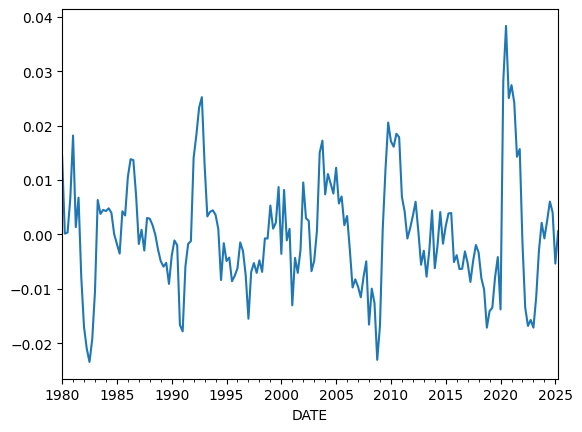

In [10]:
prod_cycle.plot()

<Axes: xlabel='DATE'>

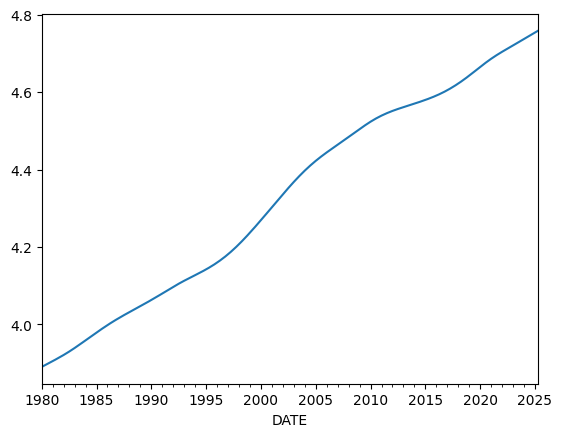

In [11]:
prod_trend.plot()

In [12]:
#prod = prod[prod.index >= "1980-01-01"]

In [13]:
# Log productivity demeaned
# prod = np.log(prod)
# a_hat = prod - prod.mean()
#a_hat = prod.rename("a_hat")

In [14]:
# prod.plot()

In [15]:
# a_hat.plot()

In [16]:
a_hat = prod_cycle

In [17]:
a = a_hat
a_lag = a.shift(1)

y = a.iloc[1:]
X = a_lag.iloc[1:].values#.reshape(-1, 1)

ar1 = OLS(y.values, X).fit()

rho_hat = ar1.params[0]
eps_hat = pd.Series(
    ar1.resid,
    index=y.index,
    name="tfp_shock"
)

print(f"Estimated rho: {rho_hat:.3f}")

Estimated rho: 0.756


<Axes: xlabel='DATE'>

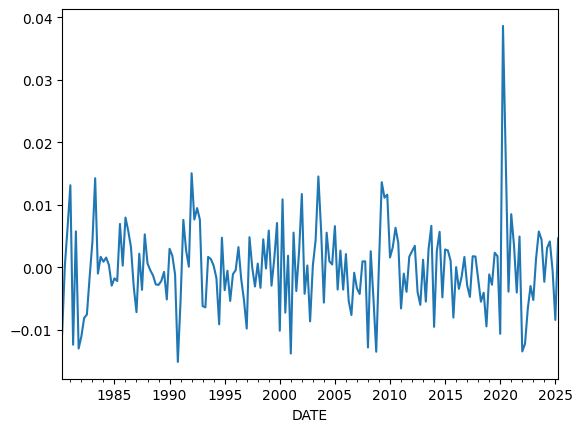

In [18]:
eps_hat.plot()

In [19]:
latest_quarter = eps_hat.index[-1]
latest_shock = eps_hat.iloc[-1]

print(f"Estimated TFP shock for {latest_quarter}: {latest_shock:.4f}")

Estimated TFP shock for 2025Q2: 0.0046


In [20]:
# Set the estimated TFP persistence coefficient as a calibrated parameter in the model
model.set_calibration(rho=rho_hat)

In [21]:
model.calibration.flat

{'e_z': 0.0,
 'z': 0.0,
 'k': 9.354978290145986,
 'n': 0.33,
 'i': 0.23387445725364966,
 'beta': 0.99,
 'sigma': 5.0,
 'eta': 1.0,
 'chi': 23.95785990938192,
 'delta': 0.025,
 'alpha': 0.33,
 'rho': 0.7559591466852725,
 'zbar': 0.0,
 'sig_z': 0.016,
 'y': 0.9950581438095304,
 'c': 0.7611836865558808,
 'rk': 0.03510101010101017,
 'w': 2.0202695647041975}

In [22]:
#dr = time_iteration(model)
dr = perturb(model, order=1)

In [23]:
irf = response(model, dr, 'e_z', T=20, impulse=float(latest_shock))

20 [0.00462207]


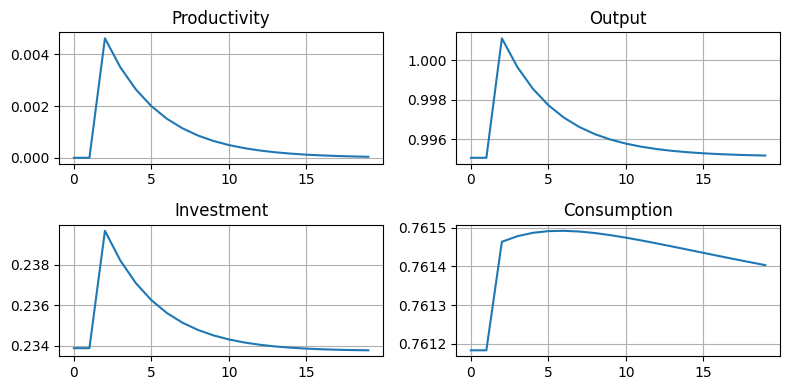

In [24]:
plt.figure(figsize=(8,4))
plt.subplot(221)
plt.plot(irf.sel(V='z'))
plt.title('Productivity')
plt.grid()
plt.subplot(222)
plt.plot(irf.sel(V='y'))
plt.title('Output')
plt.grid()
plt.subplot(223)
plt.plot(irf.sel(V='i'))
plt.title('Investment')
plt.grid()
plt.subplot(224)
plt.plot(irf.sel(V='c'))
plt.title('Consumption')
plt.grid()
plt.tight_layout()

In [25]:
irf_output = np.array(irf.sel(V='y'))

In [26]:
irf_output = [(x - 1) for x in irf_output]
output_forecast = irf_output[2]

In [27]:
print(f"Next period IRF forecast as of {latest_quarter}: {output_forecast:.5f}")

Next period IRF forecast as of 2025Q2: 0.00113


In [28]:
# Real GDP
gdp = pdr.DataReader("GDPC1", "fred", start="1980-01-01", end="2025-09-30")
gdp.index = gdp.index.to_period("Q")
gdp = gdp.dropna()

In [29]:
gdp_cycle, gdp_trend = hpfilter(np.log(gdp), lamb=1600)
output_gap = gdp_cycle

In [30]:
output_gap

DATE
1980Q1    0.033639
1980Q2    0.006845
1980Q3   -0.000339
1980Q4    0.012097
1981Q1    0.025388
            ...   
2024Q3    0.004862
2024Q4    0.002556
2025Q1   -0.005958
2025Q2   -0.003428
2025Q3    0.000392
Freq: Q-DEC, Name: cycle, Length: 183, dtype: float64

In [31]:
output_realised = output_gap.iloc[-1]

In [32]:
print(f"Current period realised value as of {output_gap.last_valid_index().strftime(None)}: {output_realised:.5f}")

Current period realised value as of 2025Q3: 0.00039


In [33]:
if output_forecast > output_realised:
    position = 1
else:
    position = -1

position

1

In [43]:
# S&P 500
asset = yf.Ticker("^GSPC").history(start="1980-01-01", end="2026-01-31")["Close"]

In [81]:
asset_ser = asset.copy()
asset_ser_name = asset_ser.index.name
asset_ser.index = asset_ser.index.date
asset_ser.index.name = asset_ser_name
asset_ser

Date
1980-01-02     105.760002
1980-01-03     105.220001
1980-01-04     106.519997
1980-01-07     106.809998
1980-01-08     108.949997
                 ...     
2026-01-26    6950.229980
2026-01-27    6978.600098
2026-01-28    6978.029785
2026-01-29    6969.009766
2026-01-30    6939.029785
Name: Close, Length: 11615, dtype: float64

<Axes: xlabel='Date'>

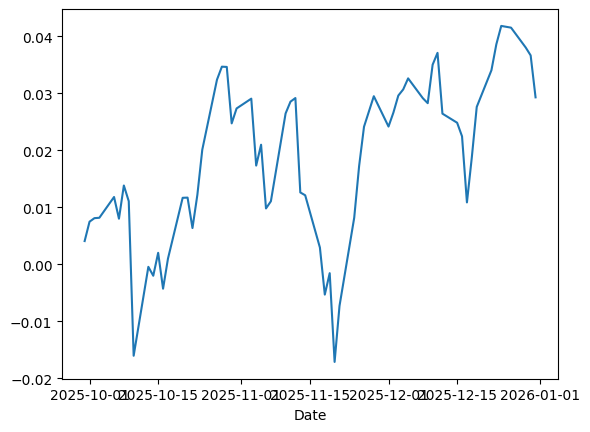

In [97]:
return_ser = asset_ser.pct_change()
return_ser.name = "Return"
# return_ser_2025q3 = return_ser.where((return_ser.index >= dt.date(2025, 9, 30)) & (return_ser.index <= dt.date(2025, 12, 31)), 0)
return_ser_2025q3 = return_ser[(return_ser.index >= dt.date(2025, 9, 30)) & (return_ser.index <= dt.date(2025, 12, 31))]
return_ser_2025q3.cumsum().plot()

In [103]:
return_ser_2025q3.sum()

0.029301988137998558

In [105]:
return_ser_2025q3_mean = return_ser_2025q3.mean()
return_ser_2025q3_mean

0.0004507998175076701

In [106]:
return_ser_2025q3_std = return_ser_2025q3.std()
return_ser_2025q3_std

0.007903444934877515

In [108]:
return_ser_2025q3_sr = return_ser_2025q3_mean / return_ser_2025q3_std
return_ser_2025q3_sr

0.05703839543669276